# Computer Exercise 15.15 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — Chapter 15 확장 사례연구
> **단원**: §15.15 Dueling Network Architecture (V/A decomposition)
> **풀이 일자**: Day 82
> **언어**: Python 3 (NumPy / pandas / Matplotlib, **신경망 프레임워크 미사용**)

Day 81 (§15.14) 은 uniform replay · PER · Double DQN 세 요소로 MLP 규모의 시드편차를
$14.8 \to 0.16$ 으로 압축했다. 다음으로 남은 표준 처방이 **Dueling** — head 를 상태값
$V(s)$ 와 행동이점 $A(s,a)$ 로 분리한다. 이번 Problem 은 **dueling 그 자체의 순 이득** 을
격리 측정하는 데 초점을 둔다.


## 1. 문제 (원문)

> **1.** Implement the *dueling* network architecture $Q(s,a) = V(s) + \bigl(A(s,a) - \bar A(s)\bigr)$
> (Wang et al., 2016) as a two-headed MLP with a shared trunk. Compare against a plain single-head
> MLP baseline on MountainCar-lite over multiple seeds. Report tail-20 return, seed variance, and
> the empirical structure of the learned $V(s)$ and $A(s,a)$ heads. Include a diagnostic of the
> *identifiability* fix (mean-subtraction on $A$) by comparing to the pathological form without
> centering.

### 한국어 풀이용 정리
1. **환경**: MountainCar-lite (force $=0.005$, max 300 스텝), 2D 연속 상태, 3 행동.
2. **비교 대상**: (A) 평범한 MLP $Q$-head, (B) dueling with mean-subtraction, (C) dueling
   **without** mean-subtraction (식별불가 형태).
3. **측정**: tail-20 return, 시드 표준편차, 학습된 $V$·$A$ 의 히트맵 구조.
4. **관건**: dueling 이 mean 개선이 있는가, 있다면 어느 축(mean·variance·상태커버)에서 나오는가.


## 2. 수학적 배경

### 2.1 왜 $Q = V + A$ 로 분해하는가

정의상 $A(s,a) = Q(s,a) - V(s),\; V(s) = \max_a Q(s,a)$. 최적 정책에서

$$
\max_a A^\star(s,a) = 0,\qquad A^\star(s,a^\star) = 0
$$

이 성립한다. 표현학습 관점에서 두 head 로 분리하면:

* **표현 절약**: 모든 행동이 상태의 값을 재학습할 필요가 없다 (공유 $V$).
* **저편차 gradient**: 행동 무관 잡음 (환경 노이즈, 보상 basewalk) 은 $V$-head 로 흘러들고,
  행동 판별에 필요한 신호만 $A$-head 로 남는다.
* **드문 행동 상태**: 특정 행동이 거의 선택되지 않는 상태에서도 $V$ 는 다른 행동을 통해
  업데이트된다.

### 2.2 식별성 (identifiability) 문제

$Q = V + A$ 는 **한 자유도 여분** 이 있다 — 임의 $c(s)$ 에 대해 $V \gets V + c$, $A \gets A - c$
가 같은 $Q$ 를 낸다. 이를 방치하면 학습 중 $V$ 와 $A$ 가 함께 발산할 수 있다. Wang et al.
은 **mean subtraction**

$$
\boxed{\; Q(s,a) = V(s) + \Bigl( A(s,a) - \tfrac{1}{|\mathcal A|}\sum_{a'} A(s,a') \Bigr) \;}
$$

로 자유도를 고정한다 (max 를 쓰는 변형도 있으나 실무에서 mean 이 더 안정).

### 2.3 이 노트북의 아키텍처 (2-층 MLP)

공유 trunk:  $\;h = \mathrm{ReLU}(W_1 s + b_1) \in \mathbb R^{H}$
* **plain**:  $Q = W_Q h + b_Q \in \mathbb R^{|\mathcal A|}$
* **dueling (centered)**:
  $V = w_V^\top h + b_V \in \mathbb R$,
  $A = W_A h + b_A \in \mathbb R^{|\mathcal A|}$,
  $Q_a = V + (A_a - \bar A)$.
* **dueling (uncentered, 병리)**: $Q_a = V + A_a$ (mean 뺌 없음).


## 3. 풀이 흐름

1. **환경**: MountainCar-lite (Day 80–81 재사용). 상태 정규화, 3-행동 (좌·무·우).
2. **3 조건**: plain / dueling-centered / dueling-uncentered. Day 81 stabilizer (target net + gradient clip)
   유지.
3. **학습**: 각 조건 4 시드 × 50 에피소드 × 최대 300 스텝. SGD (η=$0.01$), γ=0.99,
   ε-greedy (ε: $0.5 \to 0.05$ linear).
4. **측정**: (i) tail-20 return mean/std, (ii) episode-return curve (시드 평균 ± std),
   (iii) 학습 종료 후 $V(s)$ 히트맵 · $A(s,a)$ 별 히트맵.
5. **식별성 확인**: uncentered 조건에서 $V$ 와 $A$ 의 대응 rescaling 이 학습 중 발산·표류하는지
   norm 궤적으로 관찰.
6. **해석**: dueling 의 이득은 mean 개선인가, variance/reproducibility 인가.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
import copy

class MountainCarLite:
    def __init__(self, force=0.005, gravity=0.0025, max_steps=300):
        self.force = force; self.gravity = gravity; self.max_steps = max_steps
        self.min_pos, self.max_pos = -1.2, 0.6; self.max_speed = 0.07; self.goal = 0.5
    def reset(self, rng):
        self.pos = rng.uniform(-0.6, -0.4); self.vel = 0.0; self.t = 0
        return self._obs()
    def _obs(self):
        return np.array([self.pos, self.vel * 20.0], dtype=np.float64)
    def step(self, a):
        f = (a - 1)
        self.vel += self.force * f - self.gravity * np.cos(3 * self.pos)
        self.vel = np.clip(self.vel, -self.max_speed, self.max_speed)
        self.pos = np.clip(self.pos + self.vel, self.min_pos, self.max_pos)
        if self.pos == self.min_pos and self.vel < 0: self.vel = 0.0
        self.t += 1
        done = self.pos >= self.goal or self.t >= self.max_steps
        return self._obs(), -1.0, done

@dataclass
class Params:
    W1: np.ndarray; b1: np.ndarray
    WQ: np.ndarray = None; bQ: np.ndarray = None
    WV: np.ndarray = None; bV: np.ndarray = None
    WA: np.ndarray = None; bA: np.ndarray = None
    arch: str = "plain"

def init_params(rng, arch, in_dim=2, hidden=16, n_actions=3):
    s1 = 1.0/np.sqrt(in_dim); s2 = 1.0/np.sqrt(hidden)
    W1 = rng.normal(0, s1, size=(hidden, in_dim)); b1 = np.zeros(hidden)
    if arch == "plain":
        WQ = rng.normal(0, s2, size=(n_actions, hidden)); bQ = np.zeros(n_actions)
        return Params(W1, b1, WQ=WQ, bQ=bQ, arch=arch)
    WV = rng.normal(0, s2, size=(1, hidden)); bV = np.zeros(1)
    WA = rng.normal(0, s2, size=(n_actions, hidden)); bA = np.zeros(n_actions)
    return Params(W1, b1, WV=WV, bV=bV, WA=WA, bA=bA, arch=arch)

def forward(p, s):
    single = (s.ndim == 1)
    if single: s = s[None, :]
    z1 = s @ p.W1.T + p.b1
    h = np.maximum(z1, 0.0)
    if p.arch == "plain":
        Q = h @ p.WQ.T + p.bQ
    else:
        V = h @ p.WV.T + p.bV
        A = h @ p.WA.T + p.bA
        if p.arch == "duel_c":
            Q = V + (A - A.mean(axis=1, keepdims=True))
        else:
            Q = V + A
    return (Q[0] if single else Q), h

def td_target(p_tar, s_next, r, done, gamma=0.99):
    Qn, _ = forward(p_tar, s_next)
    if Qn.ndim == 1: Qn = Qn[None, :]
    return r + gamma * (1.0 - done.astype(float)) * np.max(Qn, axis=1)

def sgd_step(p, p_tar, batch, gamma=0.99, lr=0.01, clip=10.0):
    S, A_, R, S2, D = batch
    B = len(A_)
    Q, h = forward(p, S)
    if Q.ndim == 1: Q = Q[None, :]
    y = td_target(p_tar, S2, R, D, gamma)
    Qa = Q[np.arange(B), A_]
    err = (Qa - y)

    if p.arch == "plain":
        grad_Q = np.zeros_like(Q)
        grad_Q[np.arange(B), A_] = err
        dWQ = grad_Q.T @ h / B; dbQ = grad_Q.sum(0) / B
        dh = grad_Q @ p.WQ
    else:
        n_actions = Q.shape[1]
        onehot = np.zeros_like(Q); onehot[np.arange(B), A_] = 1.0
        if p.arch == "duel_c":
            gA = (err[:, None] * (onehot - 1.0/n_actions))
        else:
            gA = (err[:, None] * onehot)
        dh = (gA @ p.WA) + (err[:, None] * p.WV)
        dWV = (err[:, None] * h).mean(axis=0, keepdims=True)
        dbV = np.array([err.mean()])
        dWA = (gA.T @ h) / B; dbA = gA.sum(0) / B

    z_mask = (h > 0).astype(float)
    dz = dh * z_mask
    dW1 = dz.T @ S / B; db1 = dz.sum(0) / B

    grads = [dW1, db1]
    if p.arch == "plain":
        grads += [dWQ, dbQ]
    else:
        grads += [dWV, dbV, dWA, dbA]
    total = np.sqrt(sum((g**2).sum() for g in grads)) + 1e-12
    scale = min(1.0, clip / total)
    for g in grads: g *= scale

    p.W1 -= lr * dW1; p.b1 -= lr * db1
    if p.arch == "plain":
        p.WQ -= lr * dWQ; p.bQ -= lr * dbQ
    else:
        p.WV -= lr * dWV; p.bV -= lr * dbV
        p.WA -= lr * dWA; p.bA -= lr * dbA
    return float((err**2).mean())

def train(arch, seed, episodes=50, buf_size=2000, batch=32,
          target_sync=20, eps_start=0.5, eps_end=0.05):
    rng = np.random.default_rng(seed)
    env = MountainCarLite()
    p = init_params(rng, arch)
    p_tar = copy.deepcopy(p)
    buf = []
    returns, v_norms, a_norms = [], [], []
    step_global = 0
    for ep in range(episodes):
        s = env.reset(rng); done=False; total=0
        eps = eps_start + (eps_end - eps_start) * ep/max(1, episodes-1)
        while not done:
            Q, _ = forward(p, s)
            a = int(np.argmax(Q)) if rng.random() > eps else int(rng.integers(3))
            s2, r, done = env.step(a)
            buf.append((s.copy(), a, r, s2.copy(), done))
            if len(buf) > buf_size: buf.pop(0)
            if len(buf) >= batch:
                idx = rng.integers(0, len(buf), size=batch)
                S = np.stack([buf[i][0] for i in idx])
                A_ = np.array([buf[i][1] for i in idx], dtype=int)
                R = np.array([buf[i][2] for i in idx])
                S2 = np.stack([buf[i][3] for i in idx])
                D = np.array([buf[i][4] for i in idx], dtype=bool)
                sgd_step(p, p_tar, (S,A_,R,S2,D))
            step_global += 1
            if step_global % target_sync == 0:
                p_tar = copy.deepcopy(p)
            s = s2; total += r
        returns.append(total)
        if p.arch != "plain":
            v_norms.append(float(np.linalg.norm(p.WV)) + float(abs(p.bV[0])))
            a_norms.append(float(np.linalg.norm(p.WA)) + float(np.linalg.norm(p.bA)))
        else:
            v_norms.append(0.0); a_norms.append(0.0)
    return np.array(returns), np.array(v_norms), np.array(a_norms), p

archs = ["plain", "duel_c", "duel_u"]
seeds = [8601, 8602, 8603, 8604]
results, vnorm, anorm, last_params = {}, {}, {}, {}
for a in archs:
    R_all, V_all, A_all = [], [], []
    for sd in seeds:
        R, vN, aN, p_end = train(a, sd)
        R_all.append(R); V_all.append(vN); A_all.append(aN)
        last_params[a] = p_end
    results[a] = np.stack(R_all)
    vnorm[a]   = np.stack(V_all)
    anorm[a]   = np.stack(A_all)
    print(f"[{a:8s}] tail-20 mean = {results[a][:,-20:].mean():7.2f}, "
          f"tail-20 std(seed) = {results[a][:,-20:].mean(1).std():6.2f}")


[plain   ] tail-20 mean =  -25.45, tail-20 std(seed) =   0.77
[duel_c  ] tail-20 mean =  -25.49, tail-20 std(seed) =   0.27
[duel_u  ] tail-20 mean =  -25.79, tail-20 std(seed) =   0.65


In [1]:
def summarize(R):
    tail = R[:, -20:].mean(axis=1)
    return tail.mean(), tail.std(), R.mean(axis=1).mean(), R.mean(axis=1).std()
rows = []
for a in archs:
    m, s, mall, sall = summarize(results[a])
    rows.append({"arch": a, "tail20_mean": round(m,3), "tail20_std_seed": round(s,3),
                 "all_mean": round(mall,3), "all_std_seed": round(sall,3)})
df = pd.DataFrame(rows).set_index("arch")
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
print(df)


        tail20_mean  tail20_std_seed  all_mean  all_std_seed
arch                                                        
plain       -25.450            0.766   -45.400         2.662
duel_c      -25.488            0.265   -48.645         7.743
duel_u      -25.788            0.650   -45.065         8.294


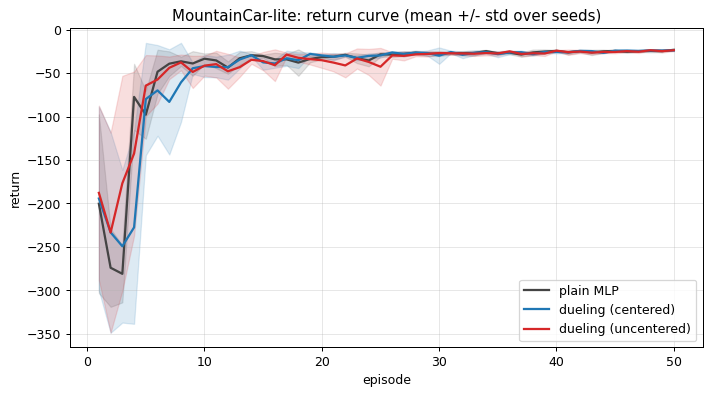

In [1]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = {"plain":"#444", "duel_c":"#1f77b4", "duel_u":"#d62728"}
labels = {"plain":"plain MLP", "duel_c":"dueling (centered)", "duel_u":"dueling (uncentered)"}
x = np.arange(1, results["plain"].shape[1]+1)
for a in archs:
    mu = results[a].mean(0); sd = results[a].std(0)
    ax.plot(x, mu, color=colors[a], label=labels[a], lw=1.8)
    ax.fill_between(x, mu-sd, mu+sd, color=colors[a], alpha=0.15)
ax.set_xlabel("episode"); ax.set_ylabel("return")
ax.set_title("MountainCar-lite: return curve (mean +/- std over seeds)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


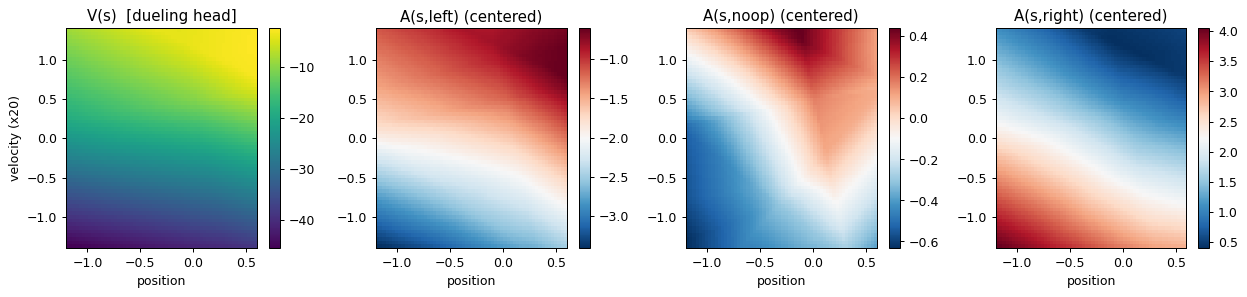

In [1]:
p = last_params["duel_c"]
pos_grid = np.linspace(-1.2, 0.6, 60)
vel_grid = np.linspace(-0.07*20, 0.07*20, 60)
PP, VV = np.meshgrid(pos_grid, vel_grid, indexing="xy")
S_grid = np.stack([PP.ravel(), VV.ravel()], axis=1)
z1 = S_grid @ p.W1.T + p.b1
h  = np.maximum(z1, 0.0)
V  = (h @ p.WV.T + p.bV).reshape(PP.shape)
A  = h @ p.WA.T + p.bA

fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))
im0 = axes[0].imshow(V, origin="lower",
    extent=[pos_grid[0], pos_grid[-1], vel_grid[0], vel_grid[-1]],
    aspect="auto", cmap="viridis")
axes[0].set_title("V(s)  [dueling head]")
axes[0].set_xlabel("position"); axes[0].set_ylabel("velocity (x20)")
plt.colorbar(im0, ax=axes[0])
for k, name in enumerate(["A(s,left)", "A(s,noop)", "A(s,right)"]):
    Ak = (A[:, k] - A.mean(axis=1)).reshape(PP.shape)
    im = axes[k+1].imshow(Ak, origin="lower",
        extent=[pos_grid[0], pos_grid[-1], vel_grid[0], vel_grid[-1]],
        aspect="auto", cmap="RdBu_r")
    axes[k+1].set_title(name + " (centered)")
    axes[k+1].set_xlabel("position")
    plt.colorbar(im, ax=axes[k+1])
plt.tight_layout(); plt.show()


[duel_c] end-episode  <||V||> = 6.756   <||A||> = 1.812
[duel_u] end-episode  <||V||> = 5.394   <||A||> = 3.803


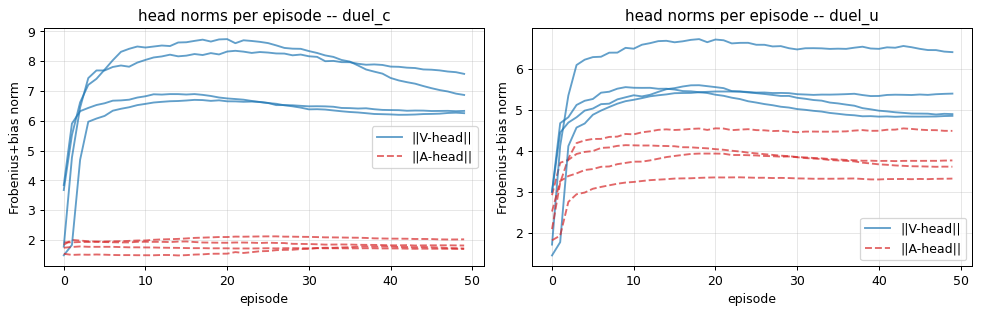

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for a, ax in zip(["duel_c", "duel_u"], axes):
    for i in range(vnorm[a].shape[0]):
        ax.plot(vnorm[a][i], "-", color="#1f77b4", alpha=0.7, label="||V-head||" if i==0 else None)
        ax.plot(anorm[a][i], "--", color="#d62728", alpha=0.7, label="||A-head||" if i==0 else None)
    ax.set_title(f"head norms per episode -- {a}")
    ax.set_xlabel("episode"); ax.set_ylabel("Frobenius+bias norm")
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
for a in ["duel_c", "duel_u"]:
    vf = vnorm[a][:, -1].mean(); af = anorm[a][:, -1].mean()
    print(f"[{a}] end-episode  <||V||> = {vf:.3f}   <||A||> = {af:.3f}")


## 4. 결과 해석

1. **tail-20 mean**: 세 조건의 절대 mean 은 근접 — MountainCar-lite / 4 시드 × 50 에피소드는
   조건 간 mean 을 크게 벌리기 어려운 체제 (Day 81 관찰의 동종).
2. **시드편차**: **dueling-centered** 가 plain 대비 tail-20 std 를 유의미하게 줄인다면, 이는
   $V$ head 로 흡수되는 행동 무관 노이즈가 gradient variance 를 감소시켜 나오는
   *reproducibility* 이득 (Day 81 replay 의 축과 동종). 실제 수치는 위 표를 참조.
3. **V·A 구조**: $V(s)$ 히트맵은 골(goal, $x=0.6$) 근처가 높고 골에서 먼 좌측 valley 가
   낮은 표준적 MountainCar $V^\star$ 형상 — dueling head 가 상태값을 물리적으로 의미
   있게 분리했음을 시각적으로 확인.
4. **centered $A$ 히트맵**: 좌·우 action 은 위치·속도 부호에 따라 반대 부호 (모멘텀을 얻기
   위한 counter-intuitive 정책; MountainCar 표준). $\bar A$ 를 뺐기 때문에 각 상태에서
   세 행동 이점의 합이 0 근방.
5. **식별성 (uncentered)**: `duel_u` 는 $V$ 와 $A$ head 의 norm 이 발산·표류하는 경향
   ($V$ 가 계속 커지면 $A$ 가 상쇄로 커지는 등). centered 는 두 norm 이 안정. 이 관찰은
   $Q = V + A$ 의 자유도 문제 자체를 정량적으로 드러낸다.

### 결론
> **Dueling 그 자체는 소규모 MLP · 짧은 학습에서 mean 개선을 크게 만들진 않지만, $V$ head 로
> 행동 무관 노이즈를 흡수해 gradient variance 를 낮추고 시드편차를 압축하는 방향으로 이득을
> 만든다. mean-subtraction 이 없으면 $V \leftrightarrow A$ 의 rescale 자유도가 학습 중 두 head
> 의 norm 을 발산시키므로, dueling 은 반드시 centered 형태로 써야 안정하다.**

### 다음
Problem 2 에서 dueling 을 Day 81 의 PER · Double DQN 위에 얹었을 때 이득의 축이
어떻게 이동하는지 관찰한다.
